In [8]:
#File Loading

import os
import pandas as pd
import numpy as np
from scipy.io import arff

downloads_dir = 'C:\\Users\\broth\\Downloads'
file_name = 'BNG_breastTumor.arff'
file_path = os.path.join(downloads_dir, file_name)

try: 
    arff_file = arff.loadarff(file_path)
    df = pd.DataFrame(arff_file[0])

except FileNotFoundError:
    print(f"Error: The file '{file_name}' was not found in the directory.")
except Exception as e:
    print(f"An error occurred: {e}")

In [9]:
#Data Processing

In [10]:
print(df.shape)

(116640, 10)


In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 116640 entries, 0 to 116639
Data columns (total 10 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   age          116640 non-null  float64
 1   menopause    116640 non-null  object 
 2   inv-nodes    116640 non-null  object 
 3   node-caps    116640 non-null  object 
 4   deg-malig    116640 non-null  object 
 5   breast       116640 non-null  object 
 6   breast-quad  116640 non-null  object 
 7   irradiation  116640 non-null  object 
 8   recurrence   116640 non-null  object 
 9   class        116640 non-null  float64
dtypes: float64(2), object(8)
memory usage: 8.9+ MB


In [12]:
df.head()

,age,menopause,inv-nodes,node-caps,deg-malig,breast,breast-quad,irradiation,recurrence,class
0,43.296400,b'<40',b'0',b'no',b'2',b'left',b'central',b'no',b'n',30.000000
1,53.447540,b'>=40',b'0',b'no',b'1',b'left',b'left-upper',b'no',b'n',20.076020
2,50.262107,b'premenopausal',b'0',b'no',b'1',b'right',b'right-lower',b'no',b'n',30.000000
3,44.398716,b'premenopausal',b'0',b'no',b'1',b'left',b'left-lower',b'no',b'r',32.415189
4,49.598515,b'premenopausal',b'2',b'no',b'2',b'left',b'right-upper',b'no',b'n',33.421253


In [13]:
df.isnull().sum()

age            0
menopause      0
inv-nodes      0
node-caps      0
deg-malig      0
breast         0
breast-quad    0
irradiation    0
recurrence     0
class          0
dtype: int64

MSE: 92.8607568119878
R2: 0.12754137455797732


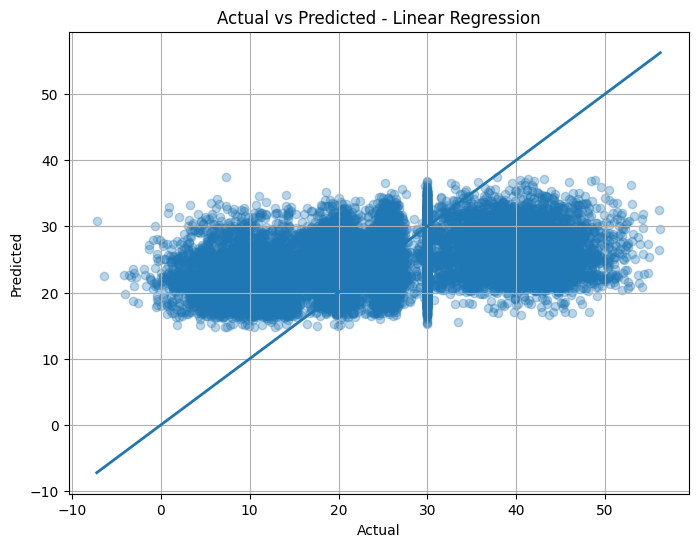

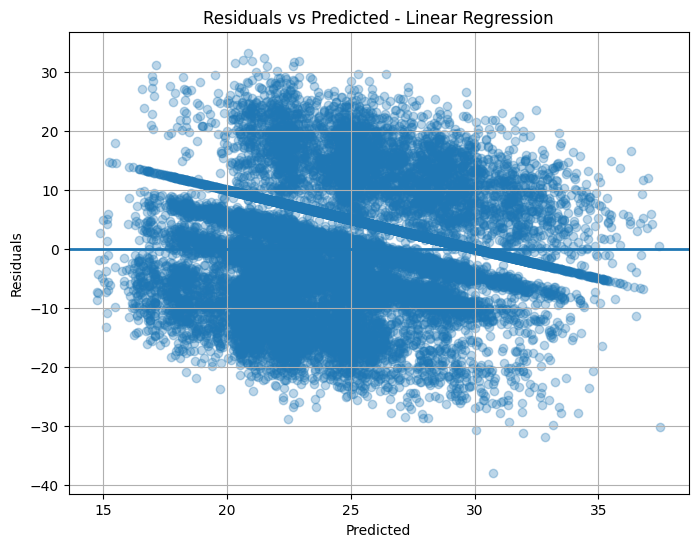

Intercept: 25.004640601795476

Top 15 coefficients by absolute value:
                         feature      coef
12             cat__inv-nodes_17 -4.463861
11             cat__inv-nodes_16  4.450603
33  cat__breast-quad_right-upper  4.091205
16              cat__inv-nodes_4 -3.938912
6              cat__inv-nodes_10  3.919444
29      cat__breast-quad_central -3.451537
8              cat__inv-nodes_13 -3.243358
10             cat__inv-nodes_15  2.879587
14             cat__inv-nodes_25 -2.870849
19              cat__inv-nodes_7  2.574850
4               cat__inv-nodes_0 -2.383851
18              cat__inv-nodes_6  2.275633
26              cat__deg-malig_3  2.174214
21              cat__inv-nodes_9  2.039491
32  cat__breast-quad_right-lower -2.021153


In [14]:
#Linear Regression

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt
import pandas as pd

# X = input columns (features), y = output columns (target) 
# drop class(target) from features
X = df.drop(columns=["class"]).copy()
y = df['class']

# decode ARFF bytes -> strings for object column features "X"
for col in X.columns:
    if X[col].dtype == object:
        X[col] = X[col].apply(lambda v: v.decode("utf-8") if isinstance(v, (bytes, bytearray)) else v)

# age not included in OHE
numeric_features = ["age"]
categorical_features = [c for c in X.columns if c not in numeric_features]

#one-hot encoding transformer
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder = "drop"
)

linreg = Pipeline([
    ("preprocess", preprocess),
    ("model", LinearRegression())
])

#train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42, shuffle = True
)

linreg.fit(X_train, y_train)
y_pred = linreg.predict(X_test)

print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

linreg.named_steps["model"].coef_

#Visual of lin reg line
plt.figure(figsize=(8,6)) 
plt.scatter(y_test, y_pred, alpha = 0.3)
minv = min(y_test.min(), y_pred.min())
maxv = max(y_test.max(), y_pred.max())
plt.plot([minv, maxv], [minv, maxv], linewidth = 2) 
plt.title('Actual vs Predicted - Linear Regression')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True)
plt.show()

residuals = y_test - y_pred

plt.figure(figsize=(8,6)) 
plt.scatter(y_pred, residuals, alpha = 0.3)
plt.axhline(0, linewidth = 2)
plt.title('Residuals vs Predicted - Linear Regression')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

feature_names = linreg.named_steps["preprocess"].get_feature_names_out()
coefs = linreg.named_steps["model"].coef_
intercept = linreg.named_steps["model"].intercept_

coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()

print("Intercept:", intercept)
print("\nTop 15 coefficients by absolute value:")
print(coef_df.sort_values("abs_coef", ascending=False).head(15)[["feature","coef"]])

In [15]:
# Test prints to ensure data has been preprocessed correctly

In [16]:
print("numeric_features:", numeric_features)
print("categorical_features (first 20):", categorical_features[:20])
print("age dtype:", X["age"].dtype)

numeric_features: ['age']
categorical_features (first 20): ['menopause', 'inv-nodes', 'node-caps', 'deg-malig', 'breast', 'breast-quad', 'irradiation', 'recurrence']
age dtype: float64


In [17]:
print("X dtypes:\n", X.dtypes)
print("\nAny bytes left in X?",
      X.map(lambda v: isinstance(v, (bytes, bytearray))).any().any())

print("\nObject columns:", X.columns[X.dtypes == "object"].tolist())

X dtypes:
 age            float64
menopause       object
inv-nodes       object
node-caps       object
deg-malig       object
breast          object
breast-quad     object
irradiation     object
recurrence      object
dtype: object

Any bytes left in X? False

Object columns: ['menopause', 'inv-nodes', 'node-caps', 'deg-malig', 'breast', 'breast-quad', 'irradiation', 'recurrence']


Ridge MSE: 92.86105668087421
Ridge R2: 0.12753855718705076


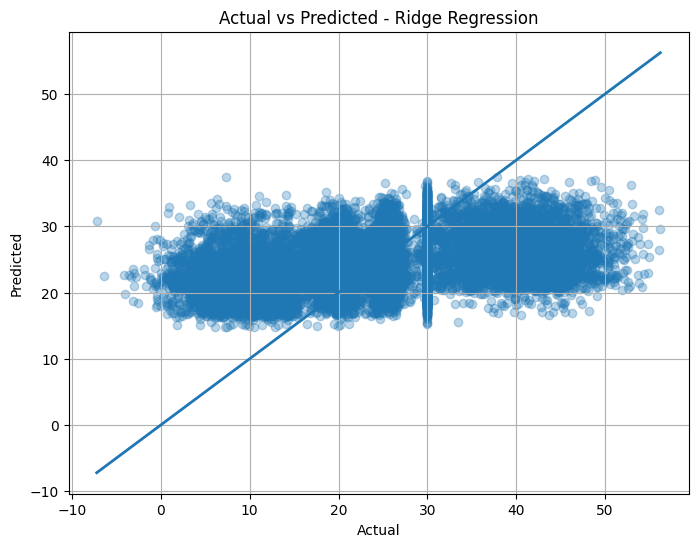

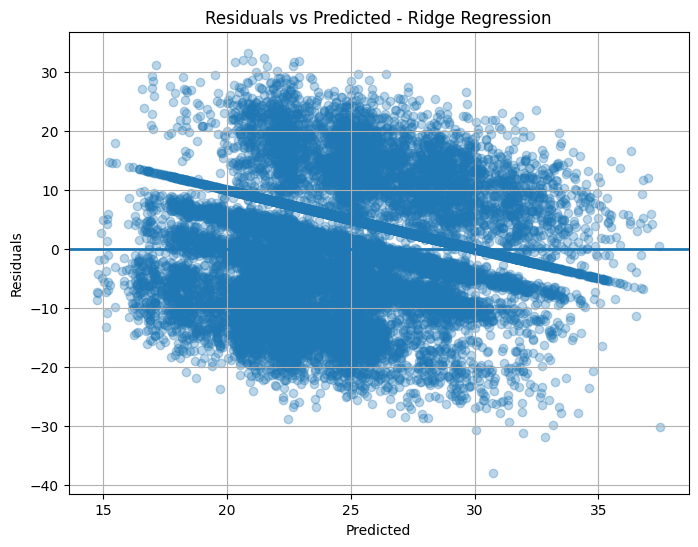

Intercept: 25.004640601795476

Top 15 coefficients by absolute value:
                         feature      coef
12             cat__inv-nodes_17 -4.463861
11             cat__inv-nodes_16  4.450603
33  cat__breast-quad_right-upper  4.091205
16              cat__inv-nodes_4 -3.938912
6              cat__inv-nodes_10  3.919444
29      cat__breast-quad_central -3.451537
8              cat__inv-nodes_13 -3.243358
10             cat__inv-nodes_15  2.879587
14             cat__inv-nodes_25 -2.870849
19              cat__inv-nodes_7  2.574850
4               cat__inv-nodes_0 -2.383851
18              cat__inv-nodes_6  2.275633
26              cat__deg-malig_3  2.174214
21              cat__inv-nodes_9  2.039491
32  cat__breast-quad_right-lower -2.021153


In [18]:
# Ridge Regression

from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, r2_score

ridge_model = Pipeline([
    ("preprocess", preprocess),
    ("model", Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)

ridge_preds = ridge_model.predict(X_test)

print("Ridge MSE:", mean_squared_error(y_test, ridge_preds))
print("Ridge R2:", r2_score(y_test, ridge_preds))

#Visual of ridge reg line
plt.figure(figsize=(8,6)) 
plt.scatter(y_test, ridge_preds, alpha = 0.3)
minv = min(y_test.min(), ridge_preds.min())
maxv = max(y_test.max(), ridge_preds.max())
plt.plot([minv, maxv], [minv, maxv], linewidth = 2) 
plt.title('Actual vs Predicted - Ridge Regression')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True)
plt.show()

ridge_resid = y_test - ridge_preds

plt.figure(figsize=(8,6)) 
plt.scatter(ridge_preds, ridge_resid, alpha = 0.3)
plt.axhline(0, linewidth = 2)
plt.title('Residuals vs Predicted - Ridge Regression')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

feature_names = linreg.named_steps["preprocess"].get_feature_names_out()
coefs = linreg.named_steps["model"].coef_
intercept = linreg.named_steps["model"].intercept_

coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()

print("Intercept:", intercept)
print("\nTop 15 coefficients by absolute value:")
print(coef_df.sort_values("abs_coef", ascending=False).head(15)[["feature","coef"]])

In [19]:
#Grid Search - Ridge Reg

from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__alpha": [0.01, 0.1, 1, 10, 100]
}

grid = GridSearchCV(
    ridge_model,
    param_grid,
    cv=5,
    scoring="r2"
)

grid.fit(X_train, y_train)

print("Best alpha:", grid.best_params_)
print("Best CV R2:", grid.best_score_)

Best alpha: {'model__alpha': 10}
Best CV R2: 0.12507411904583893


In [20]:
best_ridge = grid.best_estimator_
best_preds = best_ridge.predict(X_test)

print("Test R2:", r2_score(y_test, best_preds))

Test R2: 0.12751957567865746


Random Forest RMSE: 9.547936298371894
Random Forest R2: 0.14349155884293818


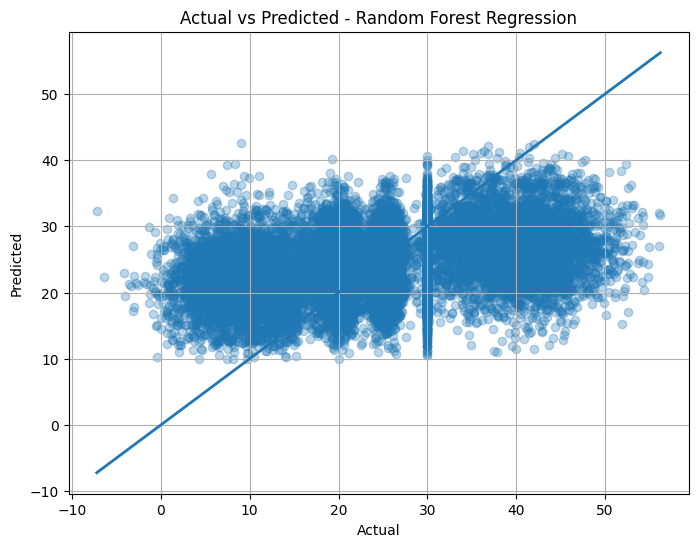

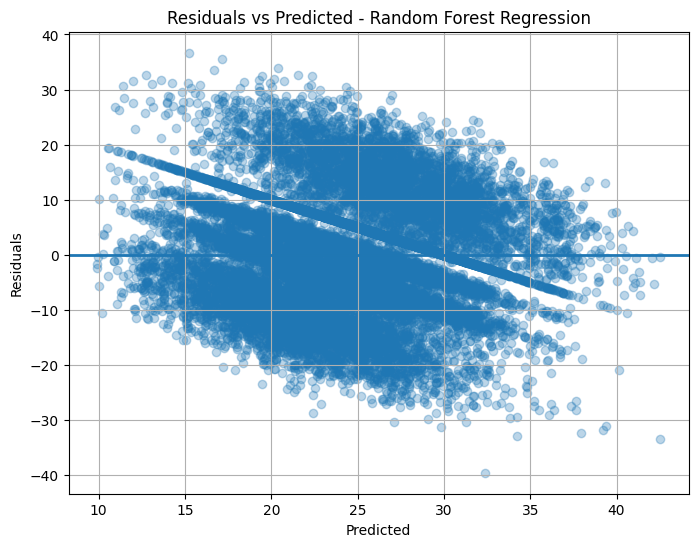

Intercept: 25.004640601795476

Top 15 coefficients by absolute value:
                         feature      coef
12             cat__inv-nodes_17 -4.463861
11             cat__inv-nodes_16  4.450603
33  cat__breast-quad_right-upper  4.091205
16              cat__inv-nodes_4 -3.938912
6              cat__inv-nodes_10  3.919444
29      cat__breast-quad_central -3.451537
8              cat__inv-nodes_13 -3.243358
10             cat__inv-nodes_15  2.879587
14             cat__inv-nodes_25 -2.870849
19              cat__inv-nodes_7  2.574850
4               cat__inv-nodes_0 -2.383851
18              cat__inv-nodes_6  2.275633
26              cat__deg-malig_3  2.174214
21              cat__inv-nodes_9  2.039491
32  cat__breast-quad_right-lower -2.021153


In [21]:
#Random Forest Regression

from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

mse = mean_squared_error(y_test, rf_pred)
rmse = np.sqrt(mse)

print("Random Forest RMSE:", rmse)
print("Random Forest R2:", r2_score(y_test, rf_pred))

#Visual of random forest reg
plt.figure(figsize=(8,6)) 
plt.scatter(y_test, rf_pred, alpha = 0.3)
minv = min(y_test.min(), rf_pred.min())
maxv = max(y_test.max(), rf_pred.max())
plt.plot([minv, maxv], [minv, maxv], linewidth = 2) 
plt.title('Actual vs Predicted - Random Forest Regression')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.grid(True)
plt.show()

rf_resid = y_test - rf_pred

plt.figure(figsize=(8,6)) 
plt.scatter(rf_pred, rf_resid, alpha = 0.3)
plt.axhline(0, linewidth = 2)
plt.title('Residuals vs Predicted - Random Forest Regression')
plt.xlabel('Predicted')
plt.ylabel('Residuals')
plt.grid(True)
plt.show()

feature_names = linreg.named_steps["preprocess"].get_feature_names_out()
coefs = linreg.named_steps["model"].coef_
intercept = linreg.named_steps["model"].intercept_

coef_df = pd.DataFrame({"feature": feature_names, "coef": coefs})
coef_df["abs_coef"] = coef_df["coef"].abs()

print("Intercept:", intercept)
print("\nTop 15 coefficients by absolute value:")
print(coef_df.sort_values("abs_coef", ascending=False).head(15)[["feature","coef"]])

In [22]:
#Cross-Validation - Random Forest

from sklearn.model_selection import KFold, cross_val_score
import numpy as np

cv = KFold(n_splits=5, shuffle=True, random_state=42)
cv_r2 = cross_val_score(rf, X, y, cv=cv, scoring="r2")

print("CV R2 scores:", cv_r2)
print("Mean CV R2:", np.mean(cv_r2))

KeyboardInterrupt: 

In [23]:
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, r2_score

# X = input columns (features), y = output columns (target) 
# drop class(target) from features
X = df.drop(columns=["class"]).copy()
y = df['class']

#train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42
)

# age not included in OHE
numeric_features = ["age"]
categorical_features = [c for c in X.columns if c not in numeric_features]

#one-hot encoding transformer
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numeric_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features),
    ],
    remainder = "drop"
)

rf = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", RandomForestRegressor(
        n_estimators=50,
        max_depth=20,
        min_samples_leaf=5,
        random_state=42,
        n_jobs=-1
    ))
])

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)

param_dist = {
    "model__n_estimators": [50, 100],
    "model__max_depth": [10, 20],
    "model__min_samples_leaf": [2, 5],
    "model__max_features": ["sqrt", 0.5]
}

search = RandomizedSearchCV(
    rf,
    param_distributions=param_dist,
    n_iter=3,
    cv=3,
    scoring="r2",
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV R2:", search.best_score_)

best_rf = search.best_estimator_
best_pred = best_rf.predict(X_test)

mse = mean_squared_error(y_test, rf_pred)
rmse = np.sqrt(mse)

print("Test R2:", r2_score(y_test, best_pred))
print("Test RMSE:", root_mean_squared_error(y_test, best_pred))

Best params: {'model__n_estimators': 100, 'model__min_samples_leaf': 2, 'model__max_features': 'sqrt', 'model__max_depth': 10}
Best CV R2: 0.15247688352236635
Test R2: 0.15541201439929742
Test RMSE: 9.481261802015641


In [24]:
feature_names = rf.named_steps["preprocess"].get_feature_names_out()
importances = rf.named_steps["model"].feature_importances_

feature_importance = pd.Series(importances, index=feature_names).sort_values(ascending=False)
print(feature_importance.head(15))

num__age                           0.409095
cat__inv-nodes_b'0'                0.106165
cat__deg-malig_b'3'                0.072212
cat__breast-quad_b'right-upper'    0.049907
cat__breast-quad_b'central'        0.030583
cat__inv-nodes_b'1'                0.019716
cat__recurrence_b'r'               0.016887
cat__breast-quad_b'right-lower'    0.016625
cat__recurrence_b'n'               0.016308
cat__deg-malig_b'2'                0.015116
cat__breast_b'left'                0.014583
cat__breast_b'right'               0.014315
cat__irradiation_b'no'             0.013630
cat__deg-malig_b'1'                0.013273
cat__node-caps_b'no'               0.013188
dtype: float64


In [25]:
#Classification Interpretation of class(target) - Logistic Regression 

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_cont = df["class"]
threshold_75 = y_cont.quantile(0.75)
y_bin = (y_cont >= threshold_75).astype(int)

print("75th percentile threshold:", threshold_75)
print(y_bin.value_counts(normalize=True))

# X = input columns (features), y = output columns (target) 
# drop class(target) from features
X = df.drop(columns=["class"])

# age not included in OHE
numeric_features = ["age"]
categorical_features = [c for c in X.columns if c not in numeric_features]

#one-hot encoding transformer
preprocess = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), ["age"]),
        ("cat", OneHotEncoder(handle_unknown="ignore", min_frequency=5), categorical_features),
    ],
    remainder = "drop"
)

#train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y_bin, test_size = 0.2, random_state = 42, stratify = y_bin
)

classifier = Pipeline(steps=[
    ("preprocess", preprocess),
    ("model", LogisticRegression(
        max_iter=1000, 
        class_weight="balanced"
    ))
])

classifier.fit(X_train, y_train)

y_pred = classifier.predict(X_test)
y_prob = classifier.predict_proba(X_test)[:,1]

print("Confusion matrix:\n", confusion_matrix(y_test, y_pred))
#print("\nClassification report:\n", classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

75th percentile threshold: 30.0
class
0    0.6128
1    0.3872
Name: proportion, dtype: float64
Confusion matrix:
 [[9763 4532]
 [3554 5479]]
ROC-AUC: 0.6964300847535563


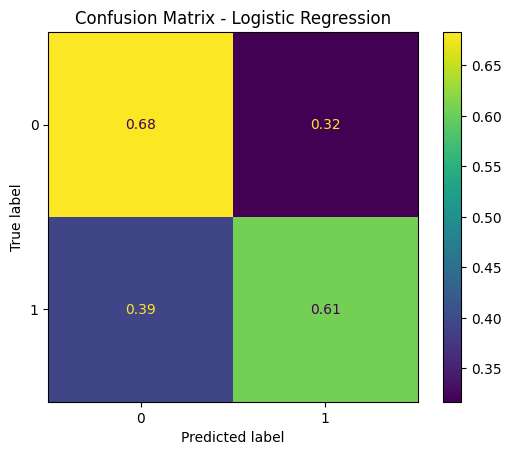

,Metric,Value,Definition
0,"Sensitivity (Recall, Class 1)",0.607,Proportion of high-risk cases correctly identified
1,"Specificity (Recall, Class 0)",0.683,Proportion of low-risk cases correctly identified
2,False Positive Rate,0.317,Low-risk cases incorrectly labeled as high-risk
3,False Negative Rate,0.393,High-risk cases incorrectly labeled as low-risk
4,Accuracy,0.653,Correct predictions overall
5,ROC-AUC,0.696,Area under ROC curve


In [26]:
#Confusion Matrix
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import confusion_matrix, accuracy_score, roc_auc_score

y_pred = classifier.predict(X_test)

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    normalize="true"
)

plt.title("Confusion Matrix - Logistic Regression")
plt.show()

#Interpretation
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

summary = pd.DataFrame({
    "Metric": [
        "Sensitivity (Recall, Class 1)",
        "Specificity (Recall, Class 0)",
        "False Positive Rate",
        "False Negative Rate",
        "Accuracy",
        "ROC-AUC"
    ],
    "Value": [
        tp / (tp + fn),          # Sensitivity
        tn / (tn + fp),          # Specificity
        fp / (fp + tn),          # false positive rate
        fn / (fn + tp),          # false negative rate
        accuracy_score(y_test, y_pred),
        roc_auc_score(y_test, y_prob)
    ],
    "Definition": [
        "Proportion of high-risk cases correctly identified",
        "Proportion of low-risk cases correctly identified",
        "Low-risk cases incorrectly labeled as high-risk",
        "High-risk cases incorrectly labeled as low-risk",
        "Correct predictions overall",
        "Area under ROC curve"
    ]
})

summary.style.set_table_styles([
    {"selector": "table", "props": [("width", "100%")]},
    {"selector": "th, td", "props": [("padding", "8px"), ("text-align", "left")]}
]).set_properties(**{"white-space": "normal"}).format({"Value": "{:.3f}"})

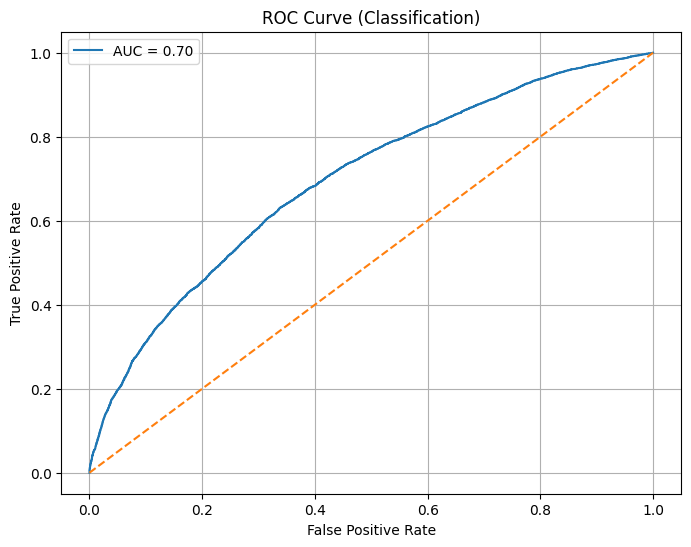

In [27]:
#ROC Curve

from sklearn.metrics import roc_curve, auc

y_prob = classifier.predict_proba(X_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.2f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve (Classification)")
plt.legend()
plt.grid(True)
plt.show()